Initial Train shape: (82332, 45)
Initial Test shape: (175341, 45)

--- Train Class Distribution (Binary) ---
label
1    0.5506
0    0.4494
Name: proportion, dtype: float64

--- Train Attack Categories ---
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


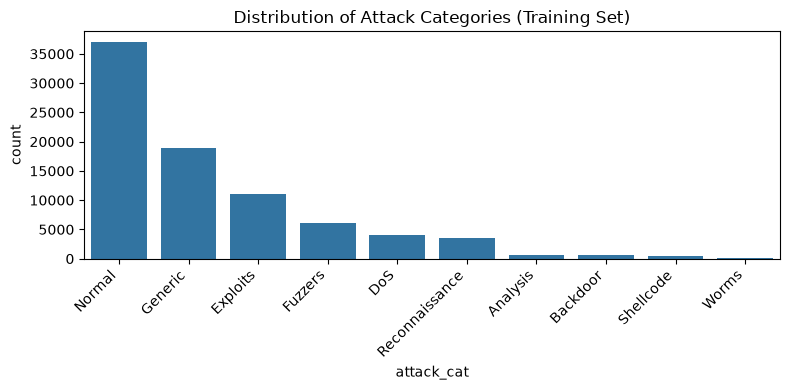


Applying transformations...
Processed Train Shape: (82332, 190)
Processed Test Shape: (175341, 190)
Saved CSV files successfully to ../data/processed/


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib
import os

# --- STEP 1: LOAD RAW DATA ---
train_path = os.path.join("..", "data", "raw", "UNSW_NB15_training-set.csv")
test_path = os.path.join("..", "data", "raw", "UNSW_NB15_testing-set.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Initial Train shape: {train_df.shape}")
print(f"Initial Test shape: {test_df.shape}")

# --- STEP 2: EXPLORATORY DATA ANALYSIS (EDA) ---
# View class balance (0 = Normal, 1 = Attack)
print("\n--- Train Class Distribution (Binary) ---")
print(train_df["label"].value_counts(normalize=True))

print("\n--- Train Attack Categories ---")
print(train_df["attack_cat"].value_counts())

# Generate a quick distribution plot for documentation
os.makedirs(os.path.join("..", "static"), exist_ok=True)
plt.figure(figsize=(8, 4))
sns.countplot(
    data=train_df, x="attack_cat", order=train_df["attack_cat"].value_counts().index
)
plt.title("Distribution of Attack Categories (Training Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join("..", "static", "eda_attack_distribution.png"))
plt.show()

# --- STEP 3: DATA CLEANING ---
# 1. Drop 'id' column (prevents overfitting to arbitrary database sequence)
train_df.drop(columns=["id"], inplace=True, errors="ignore")
test_df.drop(columns=["id"], inplace=True, errors="ignore")

# 2. Handle missing or anomalous entries
# Replace '-' with 'unknown' in categorical columns (e.g., service)
categorical_cols = ["proto", "service", "state"]
for col in categorical_cols:
    train_df[col] = train_df[col].replace("-", "unknown")
    test_df[col] = test_df[col].replace("-", "unknown")

# 3. Clean string whitespace in target attack category
train_df["attack_cat"] = train_df["attack_cat"].str.strip()
test_df["attack_cat"] = test_df["attack_cat"].str.strip()

# --- STEP 4: FEATURE & TARGET SEPARATION ---
# For binary intrusion detection
X_train = train_df.drop(columns=["label", "attack_cat"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label", "attack_cat"])
y_test = test_df["label"]

# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# --- STEP 5: PREPROCESSING PIPELINE ---
# Handle unseen categories in testing data via handle_unknown='ignore'
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
    ]
)

# Fit on training data ONLY, transform both
print("\nApplying transformations...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Test Shape: {X_test_processed.shape}")

# --- STEP 6: SAVE PROCESSED ARTIFACTS AS CSV ---
os.makedirs(os.path.join("..", "data", "processed"), exist_ok=True)

# Retrieve transformed feature names from ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# Build DataFrames with matching feature names
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Save Features to CSV
X_train_processed_df.to_csv("../data/processed/X_train_processed.csv", index=False)
X_test_processed_df.to_csv("../data/processed/X_test_processed.csv", index=False)

# Save Labels to CSV
y_train.to_csv("../data/processed/y_train.csv", index=False, header=["label"])
y_test.to_csv("../data/processed/y_test.csv", index=False, header=["label"])

# Persist the preprocessor pipeline for the Streamlit dashboard
joblib.dump(preprocessor, "../data/processed/preprocessor.joblib")

print("Saved CSV files successfully to ../data/processed/")